<a href="https://colab.research.google.com/github/pellegreeno/Bioestat-stica-2026-/blob/main/tarefa4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BIOESTATÍSTICA
Ana Carolina Sartori 17081013
Cris Serpa Guimarães 16860671
Julia Sztejnhaus Pamio 17012621
Maria Eduarda Pellegrino 17074112

- Procurar e selecionar uma base de dados real relacionada às  Ciências Biológicas, informando claramente a fonte utilizada.

- Organizar os dados selecionados em um arquivo Excel denominado tarefa4.xlsx.
Desenvolver um notebook Python denominado tarefa04.ipynb, que importe a planilha Excel e realize os cálculos e gráficos solicitados.
- Pesquisar na Biblioteca da ESALQ um livro de Estatística que apresente os conceitos de quartis, mediana, amplitude interquartílica, boxplot e observações atípicas.
- Utilizar esse livro como referência para explicar, no notebook, os conceitos teóricos empregados na atividade.
- Calcular e interpretar o primeiro quartil, o segundo quartil (mediana) e o terceiro quartil da variável selecionada.
- Construir um boxplot e apresentar uma interpretação do gráfico no contexto dos dados analisados.
- Responder, de forma clara e fundamentada, à seguinte questão: como determinamos se há observações atípicas em uma base de dados?
Informar a referência completa do livro consultado e a fonte completa dos dados utilizados.

Fonte das informações dos gráficos:  https://archive.ics.uci.edu/dataset/53/iris

Busca de informações na literatura: Introdução à Bioestatística, Sonia Vieira 4 ed. (2018) Capítulos 4 e 5

In [ ]:
import pandas as pd

df = pd.read_excel('/content/tarefa4.xlsx')
display(df.head())

,id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Verificando tipos de dados e valores não nulos
print('Informações sobre o DataFrame:')
df.info()

print('\nEstatísticas descritivas:')
display(df.describe(include='all'))

Informações sobre o DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            50 non-null     int64  
 1   sepal_length  50 non-null     float64
 2   sepal_width   50 non-null     float64
 3   petal_length  50 non-null     float64
 4   petal_width   50 non-null     float64
 5   species       50 non-null     object 
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ KB

Estatísticas descritivas:


,id,sepal_length,sepal_width,petal_length,petal_width,species
count,50.00000,50.000000,50.000000,50.000000,50.000000,50
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,NaN,17
mean,25.50000,5.808000,3.060000,3.724000,1.192000,NaN
std,14.57738,0.850891,0.461143,1.803122,0.779283,NaN
min,1.00000,4.300000,2.000000,1.100000,0.100000,NaN
25%,13.25000,5.000000,2.825000,1.500000,0.225000,NaN
50%,25.50000,5.800000,3.000000,4.450000,1.400000,NaN
75%,37.75000,6.475000,3.275000,5.100000,1.800000,NaN


In [ ]:
# Contagem de frequência da coluna 'species'
species_counts = df['species'].value_counts()
print('Contagem de Frequência das Espécies:')
display(species_counts)

# Proporção de cada espécie
species_proportions = df['species'].value_counts(normalize=True) * 100
print('\nProporção das Espécies (%):')
display(species_proportions)

# Modo (valor mais frequente) da coluna 'species'
species_mode = df['species'].mode()
print('\nModo(s) da Coluna Species:')
display(species_mode)

Contagem de Frequência das Espécies:


,count
species,
setosa,17
virginica,17
versicolor,16



Proporção das Espécies (%):


,proportion
species,
setosa,34.0
virginica,34.0
versicolor,32.0



Modo(s) da Coluna Species:


,species
0,setosa
1,virginica


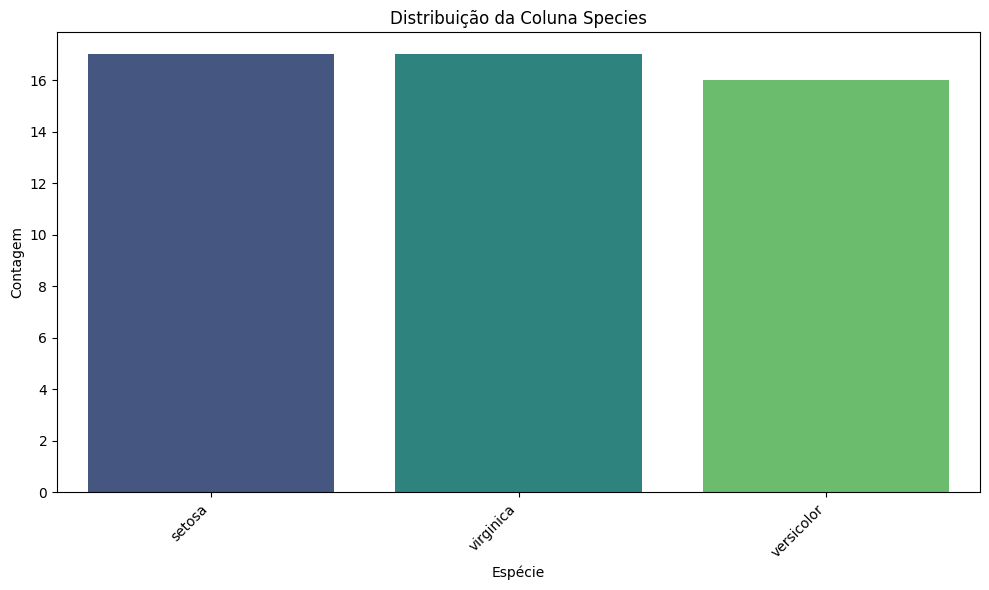

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar um gráfico de barras para a distribuição de 'species'
plt.figure(figsize=(10, 6))
sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis', hue=species_counts.index, legend=False)
plt.title('Distribuição da Coluna Species')
plt.xlabel('Espécie')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Selecionar apenas as colunas numéricas
quantitative_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Calcular os quartis para as colunas numéricas
quartiles = df[quantitative_columns].quantile([0.25, 0.5, 0.75])

print('Quartis para as Variáveis Numéricas:')
display(quartiles)

Quartis para as Variáveis Numéricas:


,sepal_length,sepal_width,petal_length,petal_width
0.25,5.000,2.825,1.50,0.225
0.50,5.800,3.000,4.45,1.400
0.75,6.475,3.275,5.10,1.800


#### Interpretação dos Quartis:

*   **Primeiro Quartil (Q1 ou 25%)**: Representa o valor abaixo do qual 25% dos dados estão localizados. Ele marca o limite inferior da metade central dos dados.
*   **Segundo Quartil (Q2 ou 50% - Mediana)**: É o valor que divide o conjunto de dados em duas metades iguais. 50% dos dados estão abaixo da mediana e 50% estão acima. É uma medida de tendência central que é menos sensível a *outliers* do que a média.
*   **Terceiro Quartil (Q3 ou 75%)**: Representa o valor abaixo do qual 75% dos dados estão localizados e acima do qual 50% dos dados estão. Ele marca o limite superior da metade central dos dados.

Esses valores nos dão uma boa ideia da distribuição dos dados, incluindo sua centralidade e dispersão, especialmente a amplitude interquartil (IQR = Q3 - Q1), que é a amplitude dos 50% centrais dos dados.

**Interpretação do grupo:**

  Ao observar esses quartis, podemos concluir que um quarto das três espécies de plantas observadas na base de dados apresentam sépalas com 5 cm ou menos de comprimento e 2.825 cm ou menos de largura, além de pétalas com 1.5 cm ou menos de comprimento e 0.225 cm ou menos de largura.

  Metade das espécies apresentam sépalas de comprimento maior que 5 cm mas menor ou igual a 5.8 cm, e de largura maior que 2.825 cm mas menor ou igual a 3 cm, além de pétalas com comprimento maior que 1.5 cm mas menor ou igual a 4.45 cm, e de largura maior que 0.225 cm mas menor ou igual a 1.4 cm.

  Três quartos das espécies apresentam sépalas de comprimento maior que 5.8 cm mas menor ou igual a 6.475 cm, e de largura maior que 3 cm mas menor ou igual a 3.275 cm, além de pétalas com comprimento maior que 4.45 cm mas menor ou igual a 5.1 cm, e de largura maior que 1.4 cm mas menor ou igual a 1.8 cm.

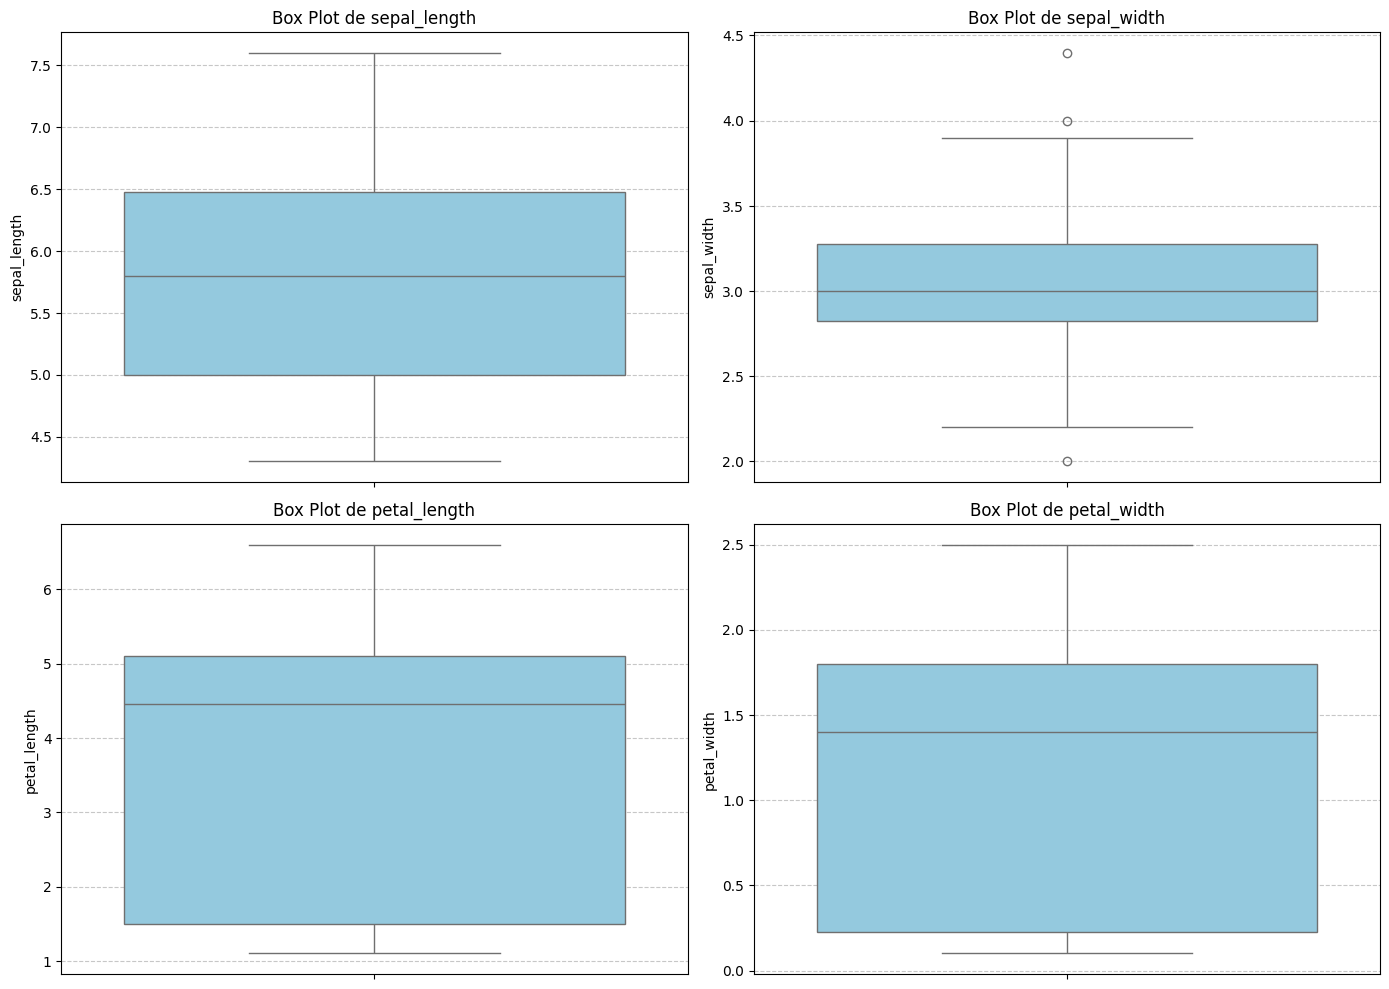

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar subplots para cada coluna numérica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

for i, col in enumerate(quantitative_columns):
    # Usando 'color' em vez de 'palette' para evitar o FutureWarning em boxplots de uma única variável
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue') # Usei 'skyblue' como uma cor única, mas poderia ser qualquer cor
    axes[i].set_title(f'Box Plot de {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Interpretação dos Box Plots:

Os *box plots* nos oferecem uma visualização rápida da distribuição de cada variável numérica, destacando:

1.  **sepal_length (Comprimento da Sépala):**
    *   O *box plot* mostra uma distribuição razoavelmente simétrica. A mediana (linha dentro da caixa) está próxima do centro da caixa, indicando que os dados não são fortemente assimétricos.
    *   A caixa é relativamente longa, sugerindo uma boa variabilidade nos comprimentos das sépalas. Não há *outliers* visíveis, o que significa que a maioria das sépalas tem comprimentos dentro de um intervalo esperado.

2.  **sepal_width (Largura da Sépala):**
    *   A mediana está ligeiramente abaixo do centro da caixa, o que pode indicar uma leve assimetria para a direita (valores mais baixos são mais concentrados).
    *   A largura da caixa é menor que a de `sepal_length`, sugerindo uma variabilidade um pouco menor. No entanto, é visível a presença de *outliers* na parte superior e inferior (pontos isolados fora dos "bigodes"), indicando que existem algumas flores com larguras de sépalas consideravelmente maiores ou menores do que a maioria.

3.  **petal_length (Comprimento da Pétala):**
    *   Este *box plot* exibe uma assimetria mais pronunciada para a esquerda, com a mediana mais próxima do Q3. Isso indica que a maioria dos comprimentos de pétala são mais longos, e há uma cauda de valores mais curtos.
    *   Há uma grande variação nos comprimentos das pétalas (a caixa é bem longa), e não há *outliers* visíveis, sugerindo que todos os comprimentos observados estão dentro da variação natural da amostra.

4.  **petal_width (Largura da Pétala):**
    *   Assim como `petal_length`, este *box plot* também mostra uma forte assimetria para a esquerda, com a mediana mais próxima do Q3. Isso sugere que as pétalas tendem a ter larguras maiores, com alguns valores menores.
    *   A caixa é longa, indicando variabilidade. Não há *outliers* visíveis neste gráfico.

Em resumo, os *box plots* nos permitiram visualizar rapidamente a centralidade, a dispersão e a presença de *outliers* para cada uma das características numéricas das flores, complementando a análise dos quartis.